In [2]:
#import sys
#print(sys.executable)

### Data Wrangling : Orders

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from pathlib import Path

# Load dataset
data_path = Path("data/raw/orders.csv")
if not data_path.exists():
    data_path = Path("../data/raw/orders.csv")  

df = pd.read_csv(data_path)
df.head()
                               

,order_id,customer_id,product_id,order_date,quantity,unit_price,discount,region,status
0,ORD10001,C1011,P039,2022-12-25,3,22.99,0.0,South,Completed
1,ORD10002,C1045,P003,2023-08-11,1,54.99,0.0,West,Completed
2,ORD10003,C1122,P010,2023-09-29,2,39.99,0.0,North,Returned
3,ORD10004,C1194,P012,2023-11-05,3,44.99,0.0,North,Completed
4,ORD10005,C1170,P022,2023-12-21,3,11.99,0.0,North,Completed


In [3]:
# Shape of dataset
df.shape

(5015, 9)

In [4]:
# Check datatypes
df.dtypes

order_id           str
customer_id        str
product_id         str
order_date         str
quantity         int64
unit_price     float64
discount       float64
region             str
status             str
dtype: object

In [9]:
# Statistical summary
df.describe()

,quantity,unit_price,discount
count,5015.000000,5015.000000,4955.000000
mean,1.957129,65.449629,0.028880
std,1.192299,52.257106,0.059777
min,-1.000000,6.990000,0.000000
25%,1.000000,29.990000,0.000000
50%,2.000000,49.990000,0.000000
75%,3.000000,89.990000,0.000000
max,5.000000,210.000000,0.200000


In [5]:
# Check null values
df.isnull().sum()


order_id        0
customer_id     0
product_id      0
order_date      0
quantity        0
unit_price      0
discount       60
region          0
status          0
dtype: int64

In [8]:
# Check for duplicate values
df.duplicated().sum()

np.int64(15)

In [33]:
# Discount column imputation
df['discount'] = df['discount'].fillna(0)

In [10]:
# Primary key uniqueness 
df['order_id'].duplicated().sum()


np.int64(15)

In [13]:
# Status and Region
print("Status",df['status'].unique())
print("Region",df['region'].unique())

Status <ArrowStringArray>
['Completed', 'Returned']
Length: 2, dtype: str
Region <ArrowStringArray>
['South', 'West', 'North', 'East']
Length: 4, dtype: str


In [20]:
# Datset correctness by status and quantity
df.loc[(df['status'] == 'Completed') & (df['quantity'] < 0), 'status'] = 'Returned'

In [26]:
df[(df['status'] == 'Completed') & (df['quantity'] < 0)]

,order_id,customer_id,product_id,order_date,quantity,unit_price,discount,region,status


In [28]:
# Nulls
print(df.isnull().sum())

# Duplicates
print(df.duplicated().sum())

# Quantity check
print(df[df['quantity'] <= 0])

# Unique categories
print(df['status'].value_counts())
print(df['region'].value_counts())

order_id        0
customer_id     0
product_id      0
order_date      0
quantity        0
unit_price      0
discount       60
region          0
status          0
dtype: int64
15
      order_id customer_id product_id  order_date  quantity  unit_price  \
410   ORD10411       C1102       P039  2023-11-03        -1       22.99   
762   ORD10763       C1018       P030  2022-08-16        -1      109.99   
1616  ORD11617       C1185       P011  2022-02-13        -1      159.99   
1698  ORD11699       C1065       P001  2022-02-05        -1       19.99   
3219  ORD13220       C1194       P023  2023-02-27        -1       22.99   
3227  ORD13228       C1150       P018  2022-02-24        -1       14.99   
4322  ORD14323       C1002       P005  2022-09-13        -1       99.99   
4570  ORD14571       C1185       P009  2023-03-06        -1       49.99   
4701  ORD14702       C1194       P001  2022-05-10        -1       19.99   
4949  ORD14950       C1063       P015  2022-10-28        -1       24.99 

In [34]:
#df['revenue'] = df['quantity'] * df['unit_price'] * (1 - df['discount'])
df['revenue'] = df['quantity'] * df['unit_price'] * (1 - df['discount'])
print(df['revenue'].head())

0     68.97
1     54.99
2     79.98
3    134.97
4     35.97
Name: revenue, dtype: float64


In [35]:
df['revenue'].describe()

count    5015.000000
mean      124.003404
std       137.467796
min      -159.990000
25%        39.990000
50%        79.980000
75%       159.980000
max      1050.000000
Name: revenue, dtype: float64

##### Note:

###### - Checked consistency between order status and quantity, and corrected cases where completed orders had negative quantities.
###### - Handled missing values in the discount column by replacing them with 0.
###### - Created a revenue column using quantity, unit price, and discount.
###### - Verified that returns are reflected as negative revenue and overall data behaves consistently.

#### Insights

In [43]:
# Top performing products
df.groupby('product_id')['revenue'].sum().sort_values(ascending=False).head(10)

# Insight: Product P007 generates highest revenue, indicating strong demand.

product_id
P007    77290.5000
P011    66403.8495
P006    54186.3315
P029    41517.9240
P005    35906.4090
P008    35874.5135
P004    29204.3490
P014    24922.7305
P030    23295.8820
P012    19071.2610
Name: revenue, dtype: float64

In [44]:
# Return rate analysis
return_rate = (df['status'] == 'Returned').mean() * 100
print(return_rate)

# Return rate is approx 8%.

8.115653040877367


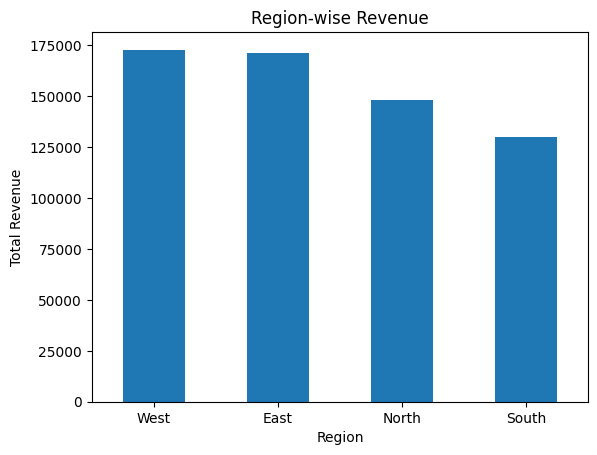

In [41]:
# Region wise revenue
region_revenue = df.groupby('region')['revenue'].sum().sort_values(ascending=False)

plt.figure()
region_revenue.plot(kind='bar')
plt.title('Region-wise Revenue')
plt.xlabel('Region')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.show()

##### - West & East region generates the highest revenue, indicating strong sales performance in that area.

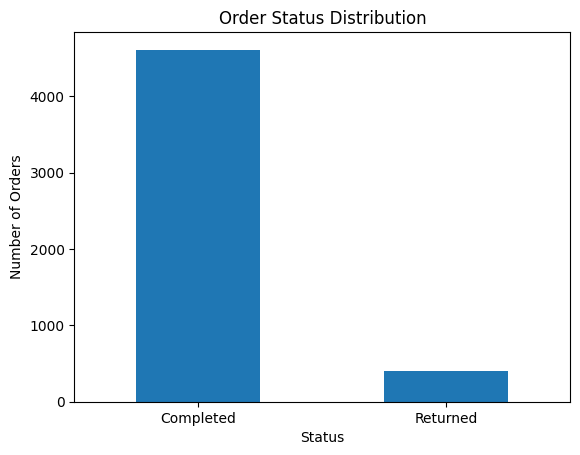

In [42]:
# Completed vs Returned Status
status_counts = df['status'].value_counts()

plt.figure()
status_counts.plot(kind='bar')
plt.title('Order Status Distribution')
plt.xlabel('Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.show()

##### - Majority of orders are completed, with a smaller proportion of returns, showing overall healthy order fulfillment.